# Blood-Cell MiniResNet Classification

> This project was originally completed as part of university coursework and has been reorganised and documented for professional portfolio presentation.

This notebook develops a compact residual neural network for eight-class blood-cell image classification. The university-provided images are excluded because public redistribution permission has not been confirmed. This is an academic image-classification study, not a clinical diagnostic system.

## Dataset access and dependencies

Set `BLOOD_CELL_DATA_DIR` to a lawful local dataset copy containing `train/` and `test/`. Required libraries are NumPy, OpenCV, Pillow, Matplotlib, scikit-learn, PyTorch and Torchvision.

## Verified evaluation context

The strongest recorded peak validation accuracy is 97.66%. A separately loaded in-memory best-model state produced 96.88% accuracy, 96.86% macro F1 and 99.75% macro ROC-AUC. Test accuracy is unavailable because test labels were not provided, and no trained checkpoint is distributed.


In [2]:
"""
MiniResNet: A Lightweight Residual Architecture for Blood Cell Image Classification
Full training + evaluation pipeline (matches the accompanying report).

"""
 
# 1. IMPORTS
import os
import cv2
import json
import time
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2. PATHS + CLASS MAP + RUNTIME SEED

working_directory = Path.cwd().resolve()
project_directory = working_directory.parent if working_directory.name == "notebooks" else working_directory
data_root = Path(os.environ.get("BLOOD_CELL_DATA_DIR", project_directory / "data"))
train_dir = data_root / "train"
test_dir = data_root / "test"
missing_paths = [str(path) for path in (train_dir, test_dir) if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Blood-cell images are not distributed in this repository. "
        "Set BLOOD_CELL_DATA_DIR to a lawful local dataset copy. "
        f"Missing: {missing_paths}"
    )

class_map = {
    "basophil": 0, "eosinophil": 1, "erythroblast": 2, "ig": 3,
    "lymphocyte": 4, "monocyte": 5, "neutrophil": 6, "platelet": 7
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [ ]:

# 3. IMAGE INTEGRITY + BLUR DIAGNOSTICS

def check_corrupted_images(directory):
    corrupted = []
    for root, _, files in os.walk(directory):
        for f in files:
            path = os.path.join(root, f)
            try:
                img = Image.open(path)
                img.verify()
            except Exception:
                corrupted.append(path)
    return corrupted

print("Checking corrupted images...")
print(f"Corrupted (train): {len(check_corrupted_images(train_dir))}")
print(f"Corrupted (test):  {len(check_corrupted_images(test_dir))}")

def detect_blurry_images(directory, threshold=20):
    blurry = []
    for root, _, files in os.walk(directory):
        for f in files:
            path = os.path.join(root, f)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            fm = cv2.Laplacian(img, cv2.CV_64F).var()
            if fm < threshold:
                blurry.append(path)
    return blurry

print("Detecting blurred images...")
blurred = detect_blurry_images(train_dir, threshold=20)
print(f"Blurred images detected: {len(blurred)}")


# SUMMARY: TOTAL IMAGE COUNTS

def count_images(directory):
    count = 0
    for root, _, files in os.walk(directory):
        count += sum(1 for f in files if f.lower().endswith((".jpg", ".jpeg", ".png")))
    return count

total_train = count_images(train_dir)
total_test  = count_images(test_dir)

print(f"[SUMMARY] Total TRAIN images : {total_train}")
print(f"[SUMMARY] Total TEST images  : {total_test}")

plt.figure(figsize=(6,4))
plt.bar(["Train", "Test"], [total_train, total_test], color=["steelblue", "orange"])
plt.title("Dataset Image Counts")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


# SUMMARY: BLUR ANALYSIS

num_blurry = len(blurred)
num_clean  = total_train - num_blurry

print(f"[SUMMARY] Clean images : {num_clean}")
print(f"[SUMMARY] Blurry images (not removed) : {num_blurry}")

plt.figure(figsize=(6,4))
plt.bar(["Clean", "Blurry"], [num_clean, num_blurry], color=["green", "blue"])
plt.title("Blur Detection Summary")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


Checking corrupted images...


[SUMMARY] Training set size  : 2560
[SUMMARY] Validation set size: 640


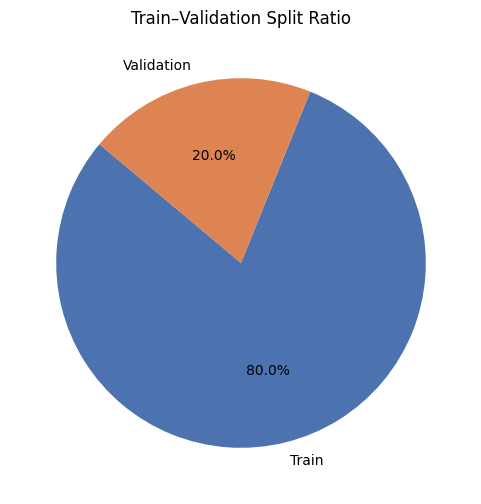

[INFO] Dataset mean: tensor([0.8734, 0.7487, 0.7216])
[INFO] Dataset std:  tensor([0.1566, 0.1820, 0.0767])


In [ ]:

# 4. BASE TRANSFORM + TRAIN/VAL SPLIT + NORMALIZATION

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_raw = datasets.ImageFolder(train_dir, transform=base_transform)

train_size = int(0.8 * len(dataset_raw))
val_size = len(dataset_raw) - train_size

train_idx, val_idx = random_split(
    range(len(dataset_raw)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


# SUMMARY: TRAIN/VALIDATION SPLIT

train_count = len(train_idx)
val_count   = len(val_idx)

print(f"[SUMMARY] Training set size  : {train_count}")
print(f"[SUMMARY] Validation set size: {val_count}")

plt.figure(figsize=(6,6))
plt.pie(
    [train_count, val_count],
    labels=["Train", "Validation"],
    autopct="%1.1f%%",
    colors=["#4c72b0", "#dd8452"],
    startangle=140
)
plt.title("Train–Validation Split Ratio")
plt.show()


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    mean = 0
    var = 0
    total = 0

    for img, _ in loader:
        img = img.view(img.size(0), img.size(1), -1)
        mean += img.mean(2).sum(0)
        var += img.var(2).sum(0)
        total += img.size(0)

    mean /= total
    var /= total
    return mean, var.sqrt()

mean, std = compute_mean_std(Subset(dataset_raw, train_idx.indices))
print(f"[INFO] Dataset mean: {mean}")
print(f"[INFO] Dataset std:  {std}")


In [ ]:

# 5. AUGMENTATION + DATA LOADERS

class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

train_tf_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
    AddGaussianNoise(0., 0.01),
    transforms.RandomErasing(p=0.5)
])

train_tf_plain = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

train_ds_aug = datasets.ImageFolder(train_dir, train_tf_aug)
train_ds_plain = datasets.ImageFolder(train_dir, train_tf_plain)
val_ds = datasets.ImageFolder(train_dir, val_tf)

train_set_aug = Subset(train_ds_aug, train_idx.indices)
train_set_plain = Subset(train_ds_plain, train_idx.indices)
val_set = Subset(val_ds, val_idx.indices)

train_loader_aug = DataLoader(train_set_aug, batch_size=32, shuffle=True)
train_loader_plain = DataLoader(train_set_plain, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

print(f"[INFO] Train samples: {len(train_set_aug)}")


[INFO] Train samples: 2560


In [ ]:

# 6. CLASS WEIGHTS

train_targets = [dataset_raw.samples[i][1] for i in train_idx.indices]
counts = np.bincount(train_targets, minlength=len(class_map))
weights = 1.0 / (counts + 1e-6)
weights = weights / weights.sum() * len(class_map)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"[INFO] Class weights: {class_weights}")


def make_criterion(weighted=True, smoothing=0.1):
    w = class_weights if weighted else None
    return nn.CrossEntropyLoss(weight=w, label_smoothing=smoothing)

[INFO] Class weights: tensor([0.9899, 0.9991, 1.0587, 1.0118, 0.9459, 0.9899, 0.9929, 1.0118],
       device='cuda:0')


In [ ]:

# 7. MODEL DEFINITIONS

class SimpleCNN(nn.Module):
    def __init__(self, nc=8):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc    = nn.Linear(32 * 56 * 56, nc)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc(x)

class MLPBaseline(nn.Module):
    def __init__(self, nc=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*224*224, 512),
            nn.ReLU(),
            nn.Linear(512, nc)
        )
    def forward(self, x):
        return self.net(x)

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)

        self.down = None
        if stride != 1 or in_c != out_c:
            self.down = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.down is not None:
            identity = self.down(identity)
        return self.relu(out + identity)

class MiniResNet(nn.Module):
    def __init__(self, nc=8):
        super().__init__()
        self.in_c = 32
        self.conv1 = nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)

        self.l1 = self._layer(32, 2, stride=1)
        self.l2 = self._layer(64, 2, stride=2)
        self.l3 = self._layer(128, 2, stride=2)
        self.l4 = self._layer(256, 2, stride=2)

        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, nc)

    def _layer(self, out_c, blocks, stride):
        layers = [BasicBlock(self.in_c, out_c, stride=stride)]
        self.in_c = out_c
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.l1(x); x = self.l2(x); x = self.l3(x); x = self.l4(x)
        x = torch.flatten(self.avg(x), 1)
        return self.fc(x)

In [ ]:

# 8. TRAINING UTILITIES

def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum = 0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        opt.zero_grad()
        out = model(X)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        loss_sum += loss.item()
        pred = out.argmax(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            pred = out.argmax(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)
    return correct / total

In [ ]:

# 9. BASELINE TRAINING

# SimpleCNN
print("Training baseline: SimpleCNN")
b1 = SimpleCNN().to(device)
opt1 = torch.optim.Adam(b1.parameters(), lr=1e-3)
crit1 = make_criterion(weighted=True)

best_acc1 = 0
for ep in range(20):
    tr_loss, tr_acc = train_epoch(b1, train_loader_aug, opt1, crit1)
    val_acc = evaluate(b1, val_loader)
    print(f"[SimpleCNN] Epoch {ep+1:02d}/20 - Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_acc1:
        best_acc1 = val_acc
        torch.save(b1.state_dict(), "best_simplecnn.pth")

print(f"[INFO] Best SimpleCNN ValAcc: {best_acc1:.4f}")


# MLPBaseline
print("[INFO] Training baseline: MLPBaseline")
b2 = MLPBaseline().to(device)
opt2 = torch.optim.Adam(b2.parameters(), lr=1e-3)
crit2 = make_criterion(weighted=True)

best_acc2 = 0
for ep in range(20):
    tr_loss, tr_acc = train_epoch(b2, train_loader_aug, opt2, crit2)
    val_acc = evaluate(b2, val_loader)
    print(f"[MLPBaseline] Epoch {ep+1:02d}/20 - Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")
    if val_acc > best_acc2:
        best_acc2 = val_acc
        torch.save(b2.state_dict(), "best_mlpbaseline.pth")

print(f"[INFO] Best MLPBaseline ValAcc: {best_acc2:.4f}")

Training baseline: SimpleCNN
[SimpleCNN] Epoch 01/20 - Train Acc: 0.3406 | Val Acc: 0.5047
[SimpleCNN] Epoch 02/20 - Train Acc: 0.5051 | Val Acc: 0.6328
[SimpleCNN] Epoch 03/20 - Train Acc: 0.5738 | Val Acc: 0.6328
[SimpleCNN] Epoch 04/20 - Train Acc: 0.6402 | Val Acc: 0.7234
[SimpleCNN] Epoch 05/20 - Train Acc: 0.6551 | Val Acc: 0.7469
[SimpleCNN] Epoch 06/20 - Train Acc: 0.6664 | Val Acc: 0.7734
[SimpleCNN] Epoch 07/20 - Train Acc: 0.6988 | Val Acc: 0.8094
[SimpleCNN] Epoch 08/20 - Train Acc: 0.7312 | Val Acc: 0.8078
[SimpleCNN] Epoch 09/20 - Train Acc: 0.7285 | Val Acc: 0.7766
[SimpleCNN] Epoch 10/20 - Train Acc: 0.7414 | Val Acc: 0.8344
[SimpleCNN] Epoch 11/20 - Train Acc: 0.7531 | Val Acc: 0.8250
[SimpleCNN] Epoch 12/20 - Train Acc: 0.7625 | Val Acc: 0.8328
[SimpleCNN] Epoch 13/20 - Train Acc: 0.7785 | Val Acc: 0.8516
[SimpleCNN] Epoch 14/20 - Train Acc: 0.7797 | Val Acc: 0.8516
[SimpleCNN] Epoch 15/20 - Train Acc: 0.8012 | Val Acc: 0.8625
[SimpleCNN] Epoch 16/20 - Train Acc: 0.80

[INFO] Training MiniResNet_full
[MiniResNet_full][Ep 01] TrainAcc: 0.3859 | ValAcc: 0.4953
[MiniResNet_full][Ep 02] TrainAcc: 0.4930 | ValAcc: 0.4703
[MiniResNet_full][Ep 03] TrainAcc: 0.6090 | ValAcc: 0.7047
[MiniResNet_full][Ep 04] TrainAcc: 0.6734 | ValAcc: 0.7812
[MiniResNet_full][Ep 05] TrainAcc: 0.6937 | ValAcc: 0.7891
[MiniResNet_full][Ep 06] TrainAcc: 0.7363 | ValAcc: 0.7328
[MiniResNet_full][Ep 07] TrainAcc: 0.7676 | ValAcc: 0.8344
[MiniResNet_full][Ep 08] TrainAcc: 0.7812 | ValAcc: 0.8109
[MiniResNet_full][Ep 09] TrainAcc: 0.7895 | ValAcc: 0.8187
[MiniResNet_full][Ep 10] TrainAcc: 0.7945 | ValAcc: 0.7750
[MiniResNet_full][Ep 11] TrainAcc: 0.8109 | ValAcc: 0.8750
[MiniResNet_full][Ep 12] TrainAcc: 0.8125 | ValAcc: 0.8625
[MiniResNet_full][Ep 13] TrainAcc: 0.8313 | ValAcc: 0.7922
[MiniResNet_full][Ep 14] TrainAcc: 0.8422 | ValAcc: 0.8047
[MiniResNet_full][Ep 15] TrainAcc: 0.8430 | ValAcc: 0.9172
[MiniResNet_full][Ep 16] TrainAcc: 0.8457 | ValAcc: 0.8719
[MiniResNet_full][Ep 17]

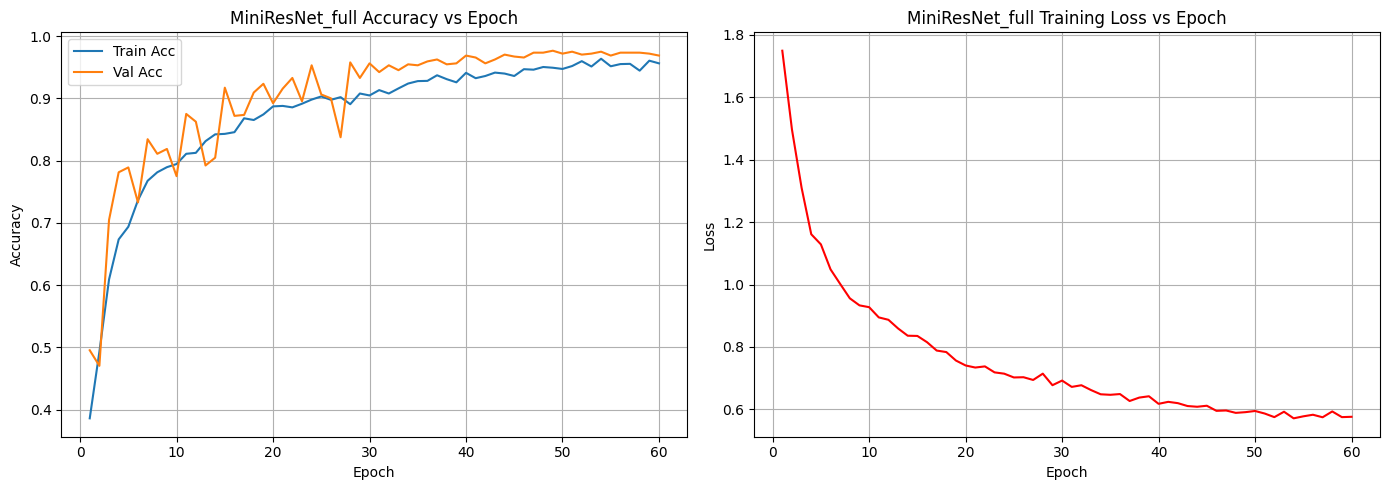

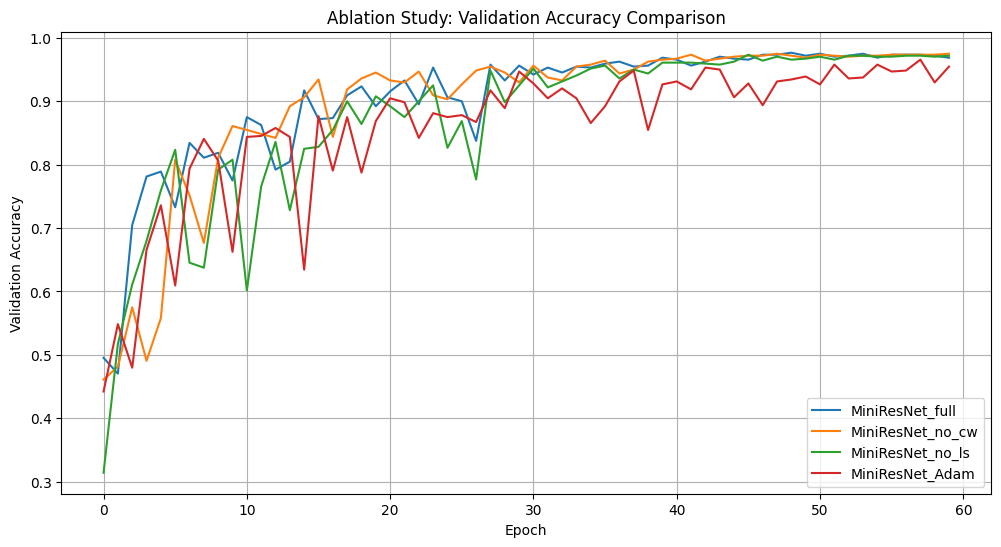

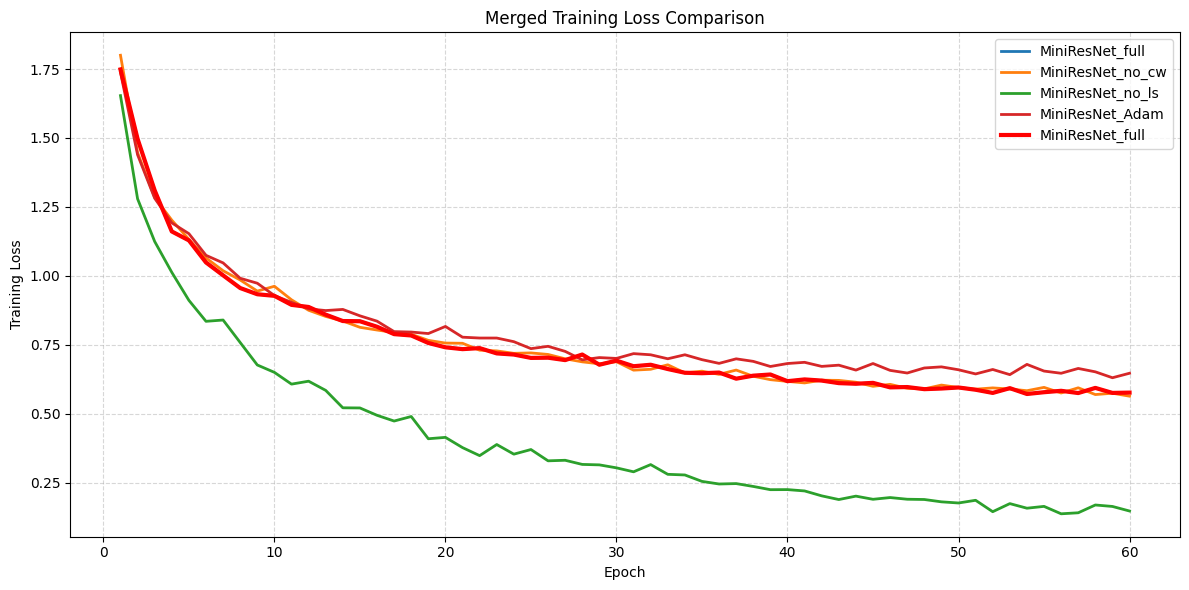

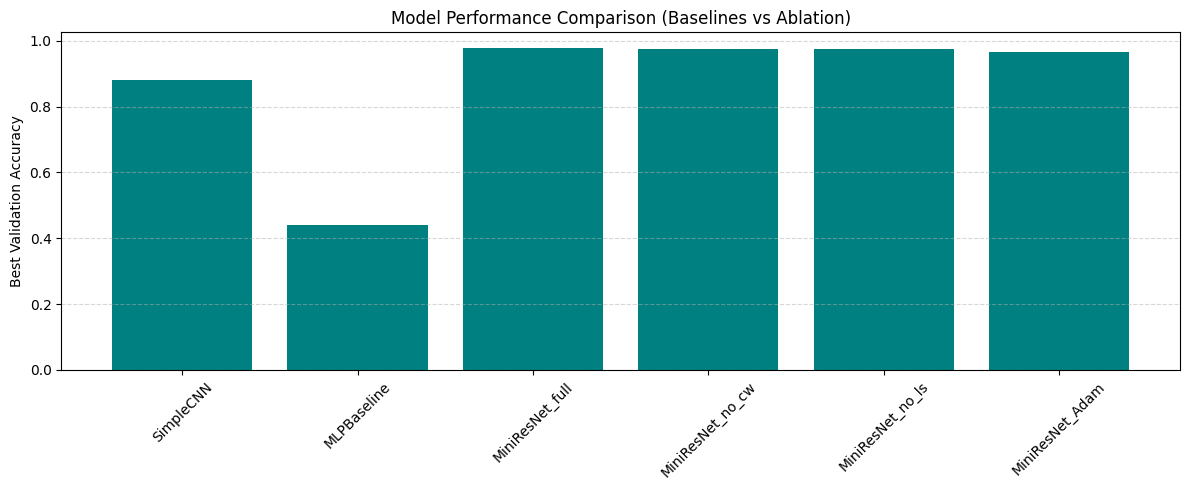

In [ ]:
# 10. ABLATION STUDY CONFIGURATIONS

configs = [
    {"name": "MiniResNet_full", "aug": True, "cw": True,  "smooth": 0.1, "opt": "adamw", "sched": True,  "lr": 1e-3, "epochs": 60},
    {"name": "MiniResNet_no_cw", "aug": True, "cw": False, "smooth": 0.1, "opt": "adamw", "sched": True,  "lr": 1e-3, "epochs": 60},
    {"name": "MiniResNet_no_ls", "aug": True, "cw": True,  "smooth": 0.0, "opt": "adamw", "sched": True,  "lr": 1e-3, "epochs": 60},
    {"name": "MiniResNet_Adam",  "aug": True, "cw": True,  "smooth": 0.1, "opt": "adam",  "sched": False, "lr": 1e-3, "epochs": 60},
]

ablation_hist = {}
best_scores = {}
best_weights = {}


for cfg in configs:
    print(f"[INFO] Training {cfg['name']}")

    loader = train_loader_aug if cfg["aug"] else train_loader_plain
    model = MiniResNet().to(device)

    # optimizer handling
    if cfg["opt"] == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])

    sched = (
        torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
        if cfg["sched"] else None
    )

    crit = make_criterion(weighted=cfg["cw"], smoothing=cfg["smooth"])

    hist = {"train_loss": [], "train_acc": [], "val_acc": []}
    best = 0
    best_w = None

    for ep in range(cfg["epochs"]):
        tr_loss, tr_acc = train_epoch(model, loader, opt, crit)
        val_acc = evaluate(model, val_loader)
        if sched: sched.step()

        hist["train_loss"].append(tr_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(val_acc)

        print(f"[{cfg['name']}][Ep {ep+1:02d}] TrainAcc: {tr_acc:.4f} | ValAcc: {val_acc:.4f}")

        if val_acc > best:
            best = val_acc
            best_w = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    ablation_hist[cfg["name"]] = hist
    best_scores[cfg["name"]] = best
    best_weights[cfg["name"]] = best_w



# 10.5. QUANTITATIVE ABLATION SUMMARY

print("\n" + "="*50)
print("ABALATION STUDY RESULTS (Best Validation Acc)")
print("="*50)

# Add baseline scores to the summary
best_scores["SimpleCNN_Baseline"] = best_acc1
best_scores["MLP_Baseline"] = best_acc2

# Sort models by performance
sorted_scores = sorted(best_scores.items(), key=lambda item: item[1], reverse=True)

for name, score in sorted_scores:
    print(f"| {name:<25} | Acc: {score:.4f} |")
print("="*50)


# LEARNING CURVES FOR MAIN MODEL

history = ablation_hist["MiniResNet_full"]
epochs = range(1, len(history["train_loss"])+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("MiniResNet_full Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Train Loss", color="red")
plt.title("MiniResNet_full Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()


# ABLATION STUDY: VALIDATION ACCURACY COMPARISON


plt.figure(figsize=(12,6))

for name, history in ablation_hist.items():
    if "val_acc" in history:
        plt.plot(history["val_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Ablation Study: Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()



# MERGED: TRAINING LOSS FOR ALL MODELS

plt.figure(figsize=(12,6))

for name, history in ablation_hist.items():
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.plot(epochs, history["train_loss"], label=name, linewidth=2)

plt.plot(
    range(1, len(ablation_hist["MiniResNet_full"]["train_loss"]) + 1),
    ablation_hist["MiniResNet_full"]["train_loss"],
    label="MiniResNet_full",
    linewidth=3,
    color="red"
)

plt.title("Merged Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# BASELINE VS RESNET COMPARISON BAR GRAPH

model_names = []
model_scores = []

# Baselines
model_names.append("SimpleCNN")
model_scores.append(best_acc1)

model_names.append("MLPBaseline")
model_scores.append(best_acc2)

# Ablation Models
for name in configs:
    model_names.append(name["name"])
    model_scores.append(best_scores[name["name"]])

plt.figure(figsize=(12,5))
plt.bar(model_names, model_scores, color="teal")
plt.ylabel("Best Validation Accuracy")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison (Baselines vs Ablation)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


<Figure size 1000x800 with 0 Axes>

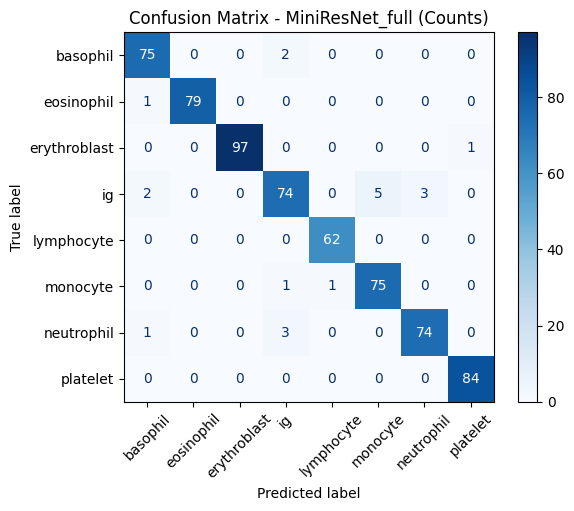


DETAILED CLASSIFICATION REPORT (MiniResNet_full)
              precision    recall  f1-score   support

    basophil     0.9494    0.9740    0.9615        77
  eosinophil     1.0000    0.9875    0.9937        80
erythroblast     1.0000    0.9898    0.9949        98
          ig     0.9250    0.8810    0.9024        84
  lymphocyte     0.9841    1.0000    0.9920        62
    monocyte     0.9375    0.9740    0.9554        77
  neutrophil     0.9610    0.9487    0.9548        78
    platelet     0.9882    1.0000    0.9941        84

    accuracy                         0.9688       640
   macro avg     0.9682    0.9694    0.9686       640
weighted avg     0.9687    0.9688    0.9686       640



<Figure size 1000x800 with 0 Axes>

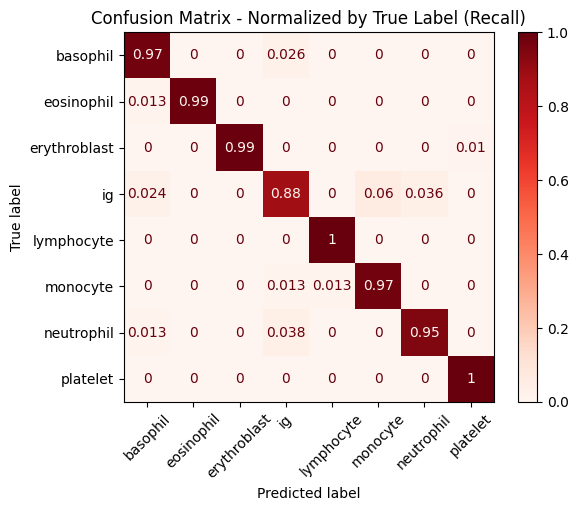

<Figure size 1000x800 with 0 Axes>

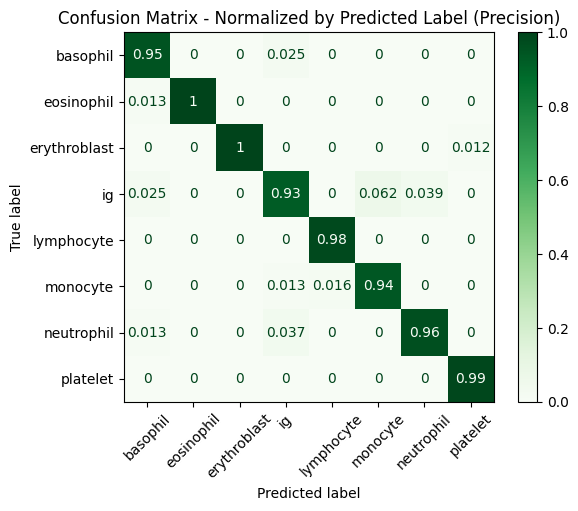

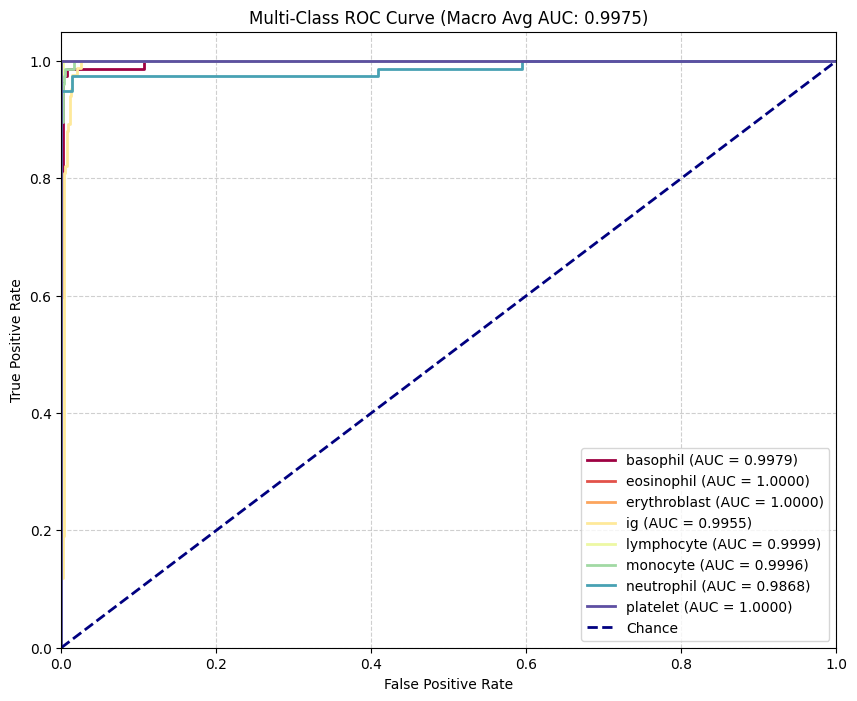

Macro-Averaged AUC: 0.9975


In [ ]:

# 11. CONFUSION MATRIX AND ROC ANALYSIS FOR MAIN MODEL

from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay

main_model = MiniResNet().to(device)
main_model.load_state_dict(best_weights["MiniResNet_full"])
main_model.eval()

y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        out = main_model(X)

        # Collect true labels and predictions
        y_true.extend(y.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())

        # Collect probability scores (used for ROC/AUC)
        y_score.extend(F.softmax(out, dim=1).cpu().numpy())

y_true_np = np.array(y_true)
y_score_np = np.array(y_score) # Shape: (N_samples, N_classes)

cm = confusion_matrix(y_true, y_pred)

# 11.1. UN-NORMALIZED CONFUSION MATRIX (Original Plot)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_map.keys()))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - MiniResNet_full (Counts)")
plt.show()


# 11.5. DETAILED PERFORMANCE REPORT

print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT (MiniResNet_full)")
print("="*50)

target_names = list(class_map.keys())
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)
print("="*50)


# 11.6. VISUALIZATION: NORMALIZED CONFUSION MATRICES


# 1. Normalizing by Row (Recall)
cm_recall = cm.astype('float')
row_sums = cm_recall.sum(axis=1)[:, np.newaxis]
cm_recall = np.divide(cm_recall, row_sums, out=np.zeros_like(cm_recall), where=row_sums != 0)

plt.figure(figsize=(10, 8))
disp_recall = ConfusionMatrixDisplay(confusion_matrix=cm_recall, display_labels=list(class_map.keys()))
disp_recall.plot(cmap="Reds", xticks_rotation=45)
plt.title("Confusion Matrix - Normalized by True Label (Recall)")
plt.show()

# 2. Normalizing by Column (Precision)
cm_precision = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
cm_precision = np.nan_to_num(cm_precision) # Handle division by zero

plt.figure(figsize=(10, 8))
disp_precision = ConfusionMatrixDisplay(confusion_matrix=cm_precision, display_labels=list(class_map.keys()))
disp_precision.plot(cmap="Greens", xticks_rotation=45)
plt.title("Confusion Matrix - Normalized by Predicted Label (Precision)")
plt.show()


# 11.7. MULTI-CLASS ROC CURVE AND AUC (NEW)

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('Spectral', len(target_names))
lw = 2
overall_auc = []

# Calculate ROC curve and AUC for each class (One-vs-Rest)
for i, class_name in enumerate(target_names):
    y_true_bin = (y_true_np == i).astype(int)
    y_score_class = y_score_np[:, i]

    # Skip if no positives or no negatives (ROC not defined)
    if y_true_bin.sum() == 0 or y_true_bin.sum() == len(y_true_bin):
        print(f"[WARN] Skipping ROC for '{class_name}' (only one class present in y_true)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score_class)
    roc_auc = auc(fpr, tpr)
    overall_auc.append(roc_auc)

    plt.plot(
        fpr, tpr,
        color=colors(i),
        lw=lw,
        label=f"{class_name} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"Multi-Class ROC Curve (Macro Avg AUC: {np.mean(overall_auc):.4f})"
    if overall_auc else "Multi-Class ROC Curve"
)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

if overall_auc:
    print(f"Macro-Averaged AUC: {np.mean(overall_auc):.4f}")
else:
    print("Macro-Averaged AUC: Not defined (no valid classes)")


## Test-set limitation

The supplied test images had no ground-truth labels, so test accuracy, F1 and ROC-AUC could not be calculated. The original coursework generated prediction identifiers, but those predictions are not distributed here because they add limited portfolio value and the source imagery is restricted. No model checkpoint is included; reproducing the trained model requires lawful dataset access and a fresh training run.
